## AGN Homework 6 – Fantastically Fitting FANTASY Spectra

#### Task

- select AGN targets from [SDSS](https://cdsarc.cds.unistra.fr/viz-bin/cat/VII/289)
- follow general FANTASY tutorial
- fine tune model input parameters
- comment on results

#### Notebook Preamble

In [1]:
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)

import numpy as np
import pandas as pd

import glob

#### Define Targets

| Plate |  MJD  | FiberID | URL |
|-------|-------|---------|-----|
|  4216 | 55477 |   310   | [spec-4216-55477-0310.fits](https://data.sdss.org/sas/dr16/eboss/spectro/redux/v5_13_0/spectra/full/4216/spec-4216-55477-0310.fits) |
|  7750 | 58402 |   802   | [spec-7750-58402-0802.fits](https://data.sdss.org/sas/dr16/eboss/spectro/redux/v5_13_0/spectra/full/7750/spec-7750-58402-0802.fits) |

#### Import Package

In [2]:
import fantasy_agn

from fantasy_agn.tools import read_sdss, read_text, read_gama_fits

from fantasy_agn.models import create_input_folder

from fantasy_agn.models import create_feii_model, create_model, create_tied_model, continuum, create_line, create_fixed_model

#### Environment Setup

In [3]:
specs = ['spec-4216-55477-0310', 'spec-7750-58402-0802', 'spec-11279-58449-0978']

print()
create_input_folder(xmin=2000,xmax=8000, path_to_folder='lists/')
print()
!ls lists/
print()

# fix "uvfe.csv" columns
df_uvfe = pd.read_csv('lists/uvfe.csv')
df_uvfe = df_uvfe.rename(columns={'ime': 'line', 'wav': 'position', 'Int': 'int'})
df_uvfe.to_csv('lists/uvfe.csv', index=False)

# restore "feII_model.csv" columns
df_feII_model = pd.read_csv('lists/feII_model.csv')
df_feII_model = df_feII_model.rename(columns={'line': 'ime', 'position': 'wav', 'int': 'Int'})
df_feII_model.to_csv('lists/feII_model.csv', index=False)

# patch "balmer.csv" columns
df_balmer = pd.read_csv('lists/balmer.csv')
df_balmer['line'] = 'H'
df_balmer.to_csv('lists/balmer.csv', index=False)


Directory  lists/  already exists

balmer.csv   feII_forbidden.csv  helium.csv	   narrow_plus.csv
broad.csv    feii_IZw1.csv	 hydrogen.csv	   oiii_nii.csv
coronal.csv  feII_model.csv	 narrow_basic.csv  uvfe.csv




Host contribution is negliglable



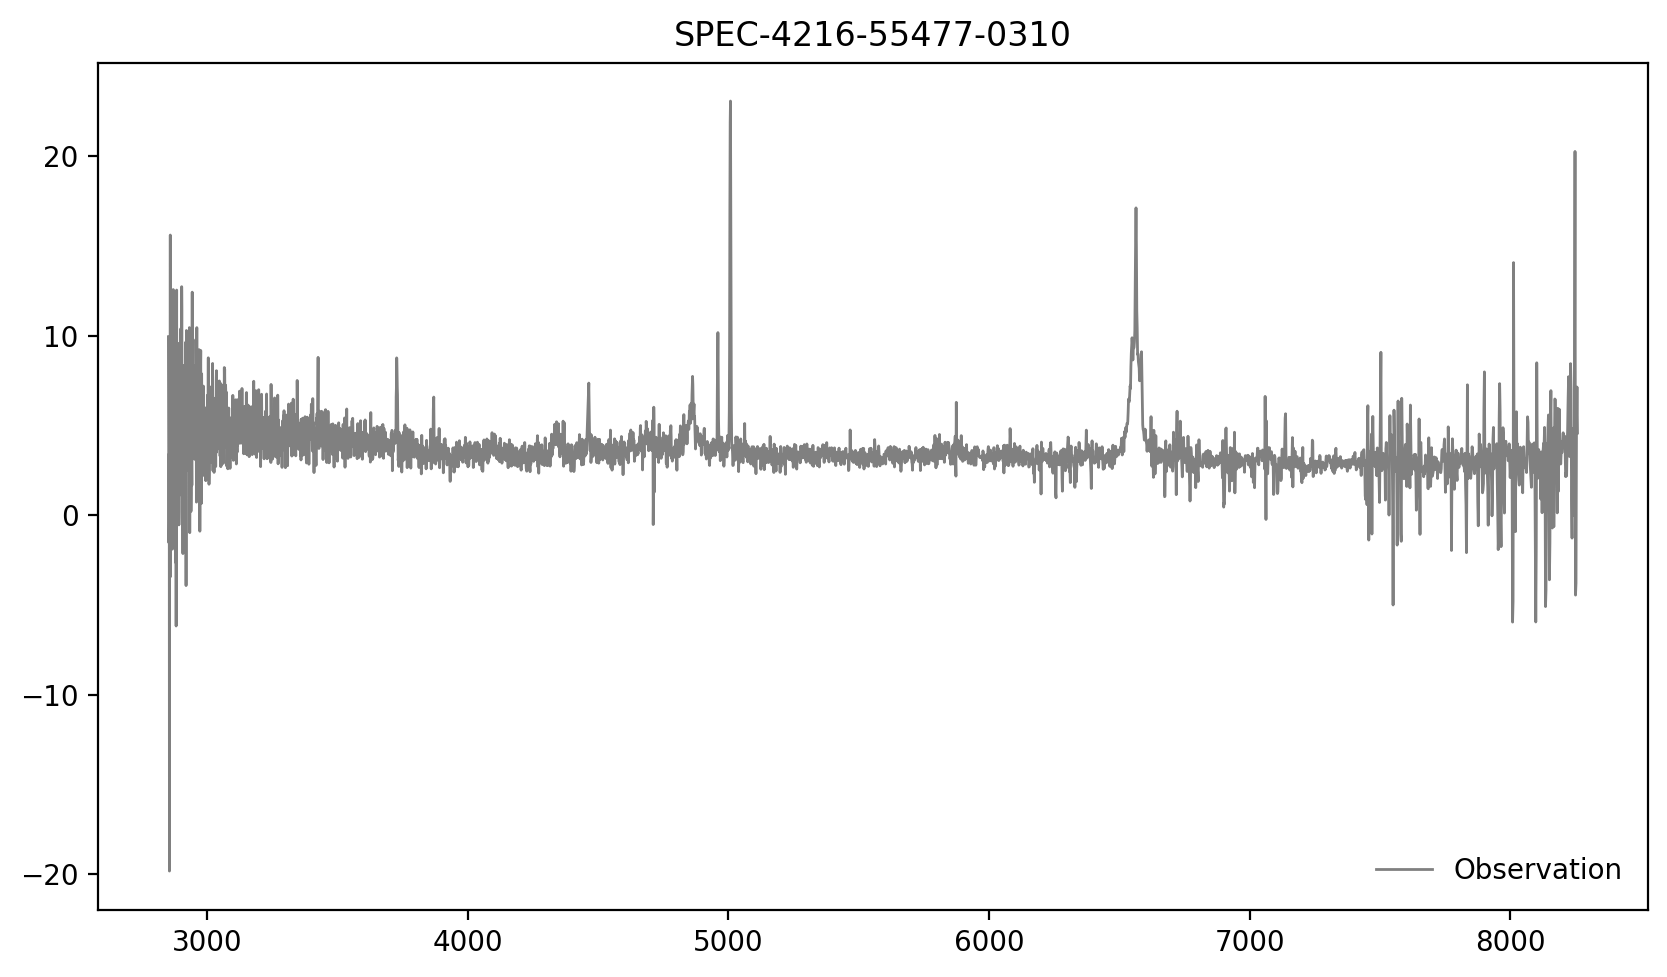

CROPPING...

min: 3500.17
max: 6999.91
len: 3011

FITTING...

iteration:  1
iteration:  2

PLOTTING...



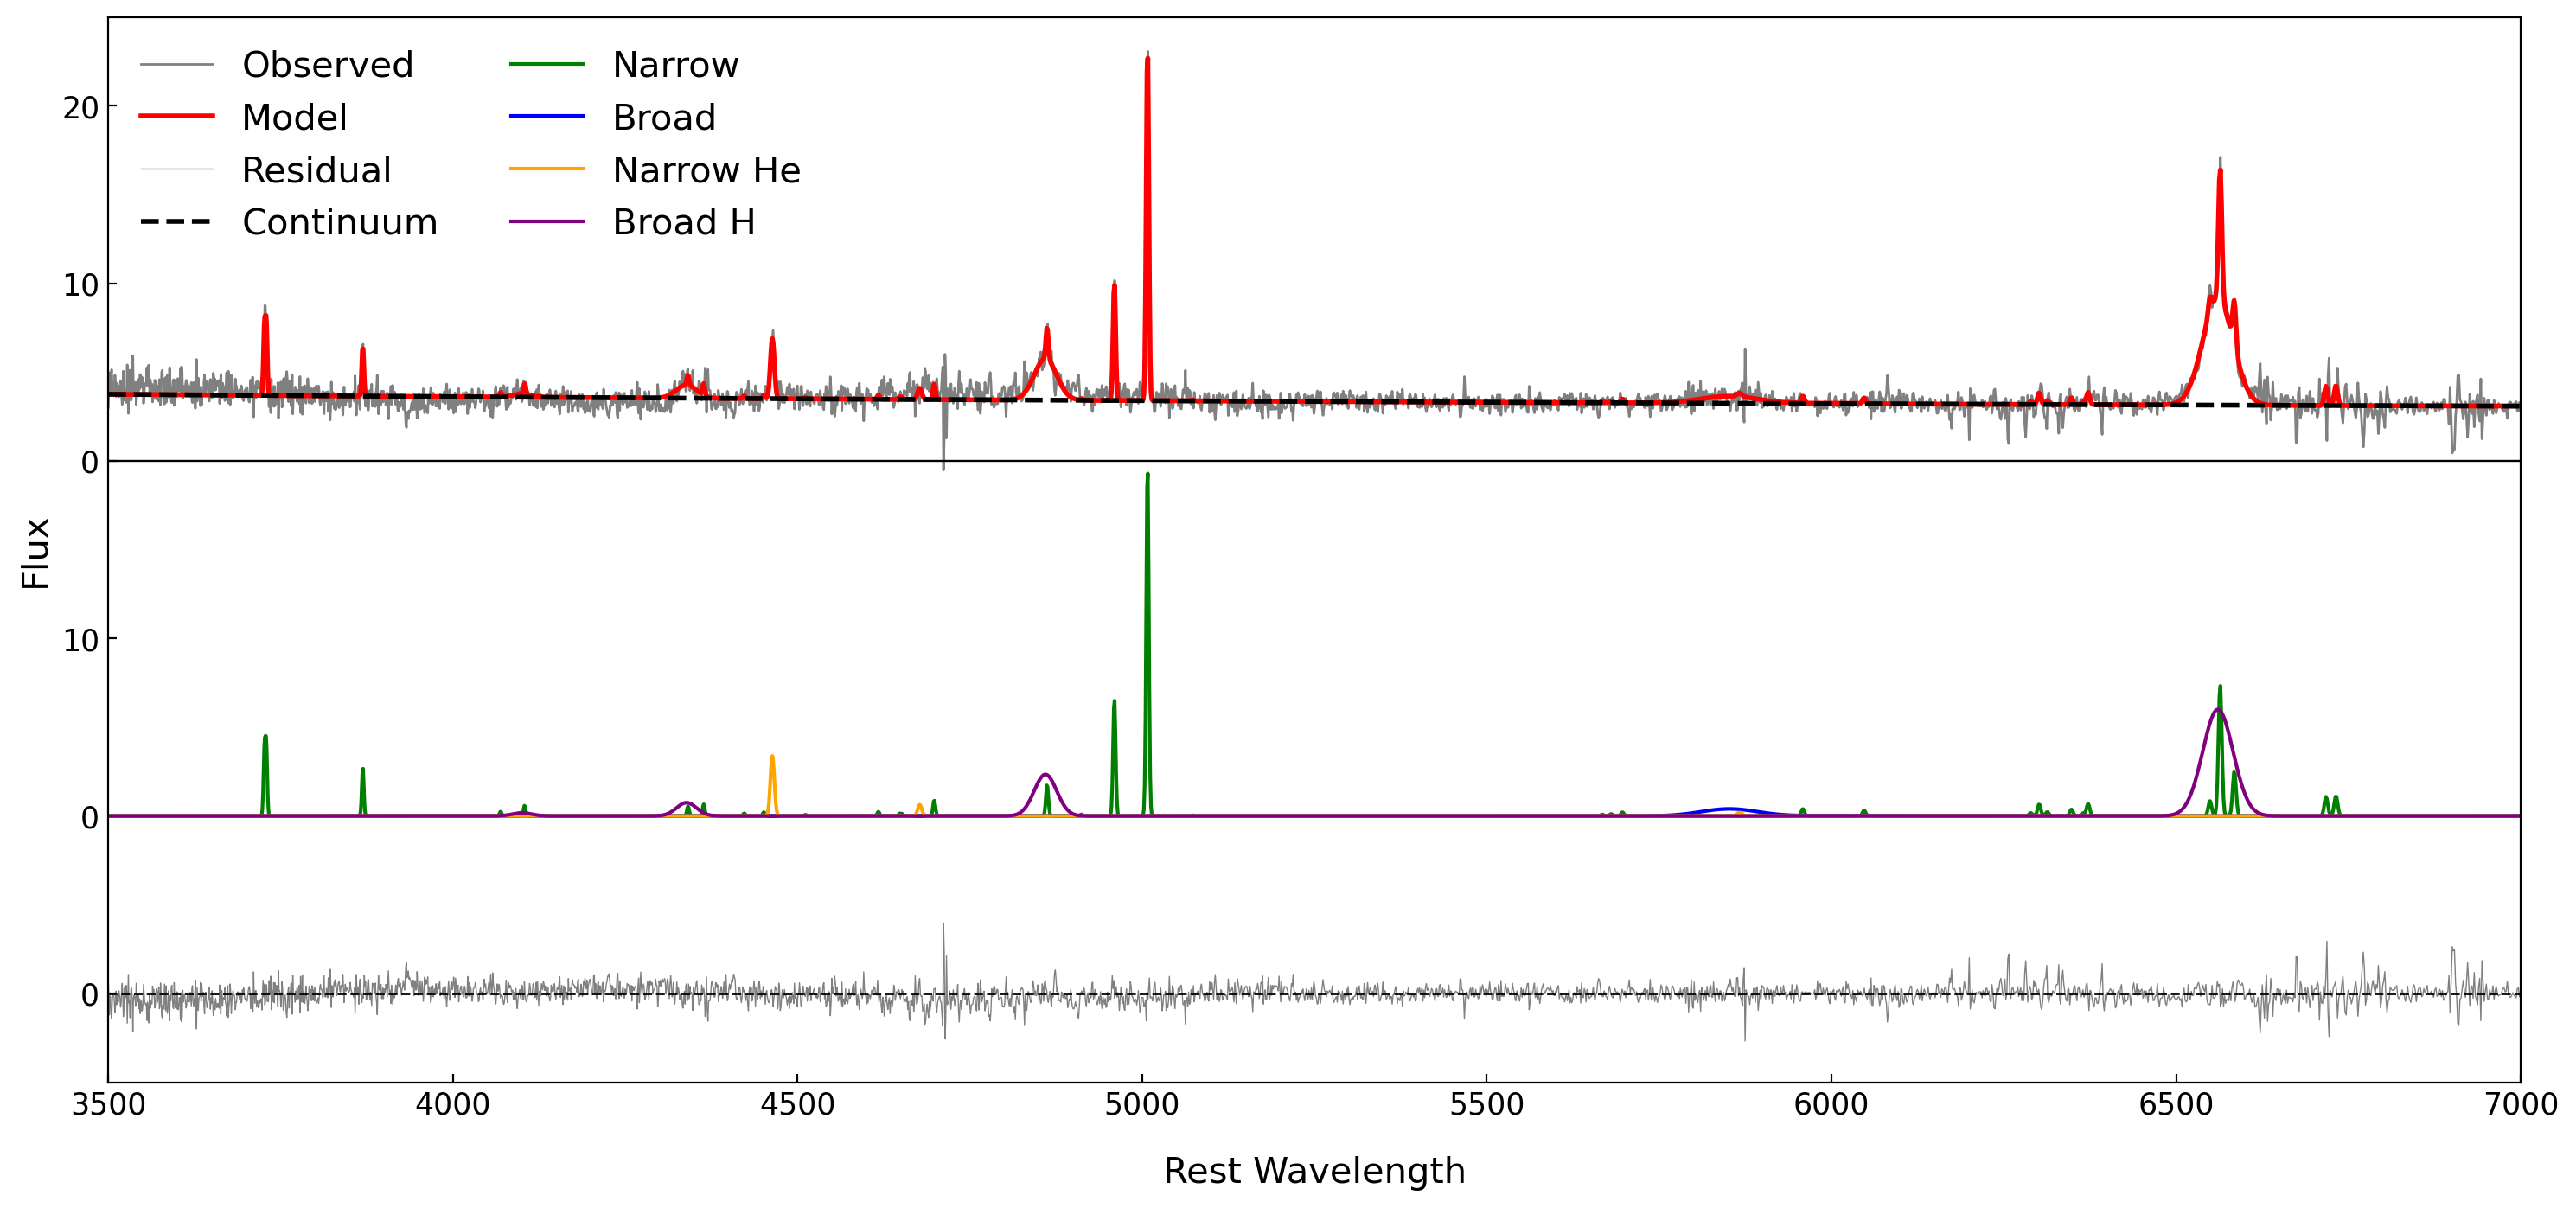


Method                = levmar
Statistic             = chi2
Initial fit statistic = 3862.12
Final fit statistic   = 3860.83 at function evaluation 1750
Data points           = 3011
Degrees of freedom    = 2915
Probability [Q-value] = 9.91778e-30
Reduced statistic     = 1.32447
Change in statistic   = 1.28959
   brokenpowerlaw.refer   5431.2       +/- 17652.5     
   brokenpowerlaw.ampl   3.31214      +/- 3.05505     
   brokenpowerlaw.index1   -0.28287     +/- 0.0214003   
   brokenpowerlaw.index2   -0.00276983  +/- 0.0571322   
   br.amp_MgII_2800   2            +/- 0           
   br.amp_NaI_5890   0.39429      +/- 5.51916     
   br.amp_NaI1_5896   0.00662458   +/- 5.57362     
   br.amp_OI_6046   0.0247937    +/- 0.0482008   
   br.amp_OI_7002   0            +/- 0.0737941   
   br.amp_OI_7254   104.787      +/- 1034.82     
   br.amp_OI_7774   2            +/- 0           
   br.offs_kms    -1944.39     +/- 4236.38     
   br.fwhm        4925.51      +/- 1202.13     
   brh.amp_He

In [4]:
s=read_sdss(f'spectra/{specs[0]}.fits')

s.DeRedden()

s.CorRed()

print()
s.fit_host_sdss(mask_host=True, custom=False)
print()

plt.style.context(['nature', 'notebook'])
plt.figure(figsize=(10,5.5))
plt.title(specs[0].upper())
plt.plot(s.wave, s.flux, color="gray", label='Observation', lw=1)
plt.legend(loc='lower right',  prop={'size': 10}, frameon=False, ncol=2)

plt.show()
plt.close()

print('CROPPING...')
s.crop(3500, 7000)
print(f'\nmin: {min(s.wave):.2f}\nmax: {max(s.wave):.2f}\nlen: {len(s.wave)}\n')

s_cont=continuum(s, refer=5500)
s_broad=create_fixed_model(['broad.csv'], name='br')
s_br_h=create_fixed_model(['hydrogen.csv'], name='brh')
s_narrow=create_tied_model(name='OIII5007', files=['narrow_basic.csv','narrow_plus.csv','hydrogen.csv'], prefix='nr', fwhm=1000, min_offset=0, max_offset=300, min_fwhm=200, max_fwhm=1800, fix_oiii_ratio=True, position=5007, included=True)
s_nr_he=create_fixed_model(['helium.csv'], name='nrhe', fwhm=250, min_fwhm=50, max_fwhm=450)

s_model = s_cont+s_broad+s_br_h+s_narrow+s_nr_he

print('FITTING...\n')
s.fit(s_model, ntrial=2)
print('\nPLOTTING...\n')

plt.style.context(['nature', 'notebook'])
plt.figure(figsize=(18,8))
plt.plot(s.wave, s.flux, label='Observed', color="gray", lw=1)
plt.plot(s.wave, s_model(s.wave), label='Model', color="red", lw=2)
plt.axhline(y=0, color='black', linestyle='-', lw=0.85)
plt.plot(s.wave, s_model(s.wave) - s.flux - 30, '-', label='Residual', color="gray", lw=0.5)
plt.axhline(y=-30, color='black', linestyle='--', lw=1)

plt.plot(s.wave, s_cont(s.wave), '--', label='Continuum', color="black", lw=2)
plt.plot(s.wave, s_narrow(s.wave) - 20, label='Narrow', color="green", lw=1.5)
plt.plot(s.wave, s_broad(s.wave) - 20, label='Broad', color="blue", lw=1.5)
plt.plot(s.wave, s_nr_he(s.wave) - 20, label='Narrow He', color="orange", lw=1.5)
plt.plot(s.wave, s_br_h(s.wave) - 20, '-', label='Broad H', color="purple", lw=1.5)

plt.xlabel('Rest Wavelength',fontsize=15, labelpad=15)
plt.ylabel('Flux',fontsize=15)
plt.xlim(3500,7000)
plt.ylim(-35,25)
plt.tick_params(which='both', direction="in")
plt.xticks(np.arange(3500, 7500, 500), fontsize=12.5)
plt.yticks(np.arange(-30, 30, 10), ['0', '0', '10', '0', '10', '20'], fontsize=12.5)
plt.legend(loc='upper left',  prop={'size': 15}, frameon=False, ncol=2)

plt.show()
plt.close()

print()
print(s.gres.format())

- optical rest frame wavelength window
- flat continuum tail of nonstellar accretion disk thermal spectrum
- hot broad line kinematics with strongly resolved Hα, Hβ, Hγ at fixed FWHM ~ 2400 km/s
- narrow line region distincly cooler with FWHM ~ 260 km/s anchored by [OIII] transition
- velocity shear between offsets of NLR ~ 50 km/s redshift and BLR ~ -100 km/s blueshift could be indicator of outflowing gas
- enriched environment with prominent [NeIII], [OII], [SII] narrow lines fitted

*--> Unobscured Seyfert (face on view inside central region, moderate velocity supermassive black hole engine)*


Host contribution is negliglable



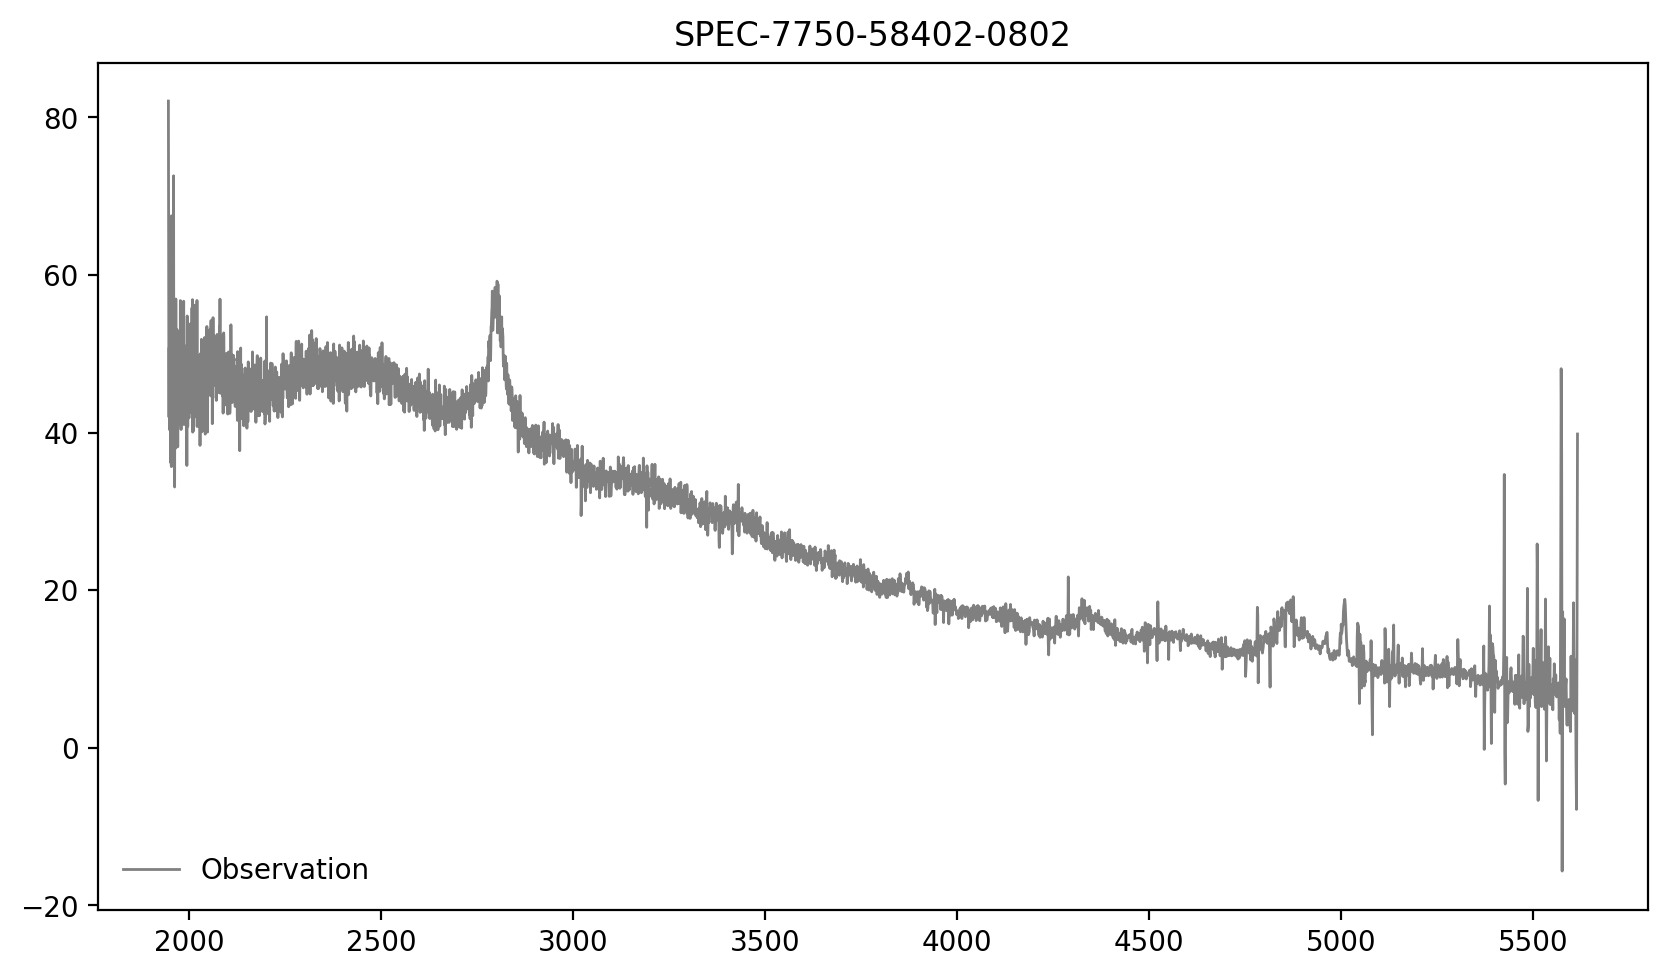

CROPPING...

min: 2250.50
max: 5249.07
len: 3679

FITTING...

iteration:  1
iteration:  2

PLOTTING...



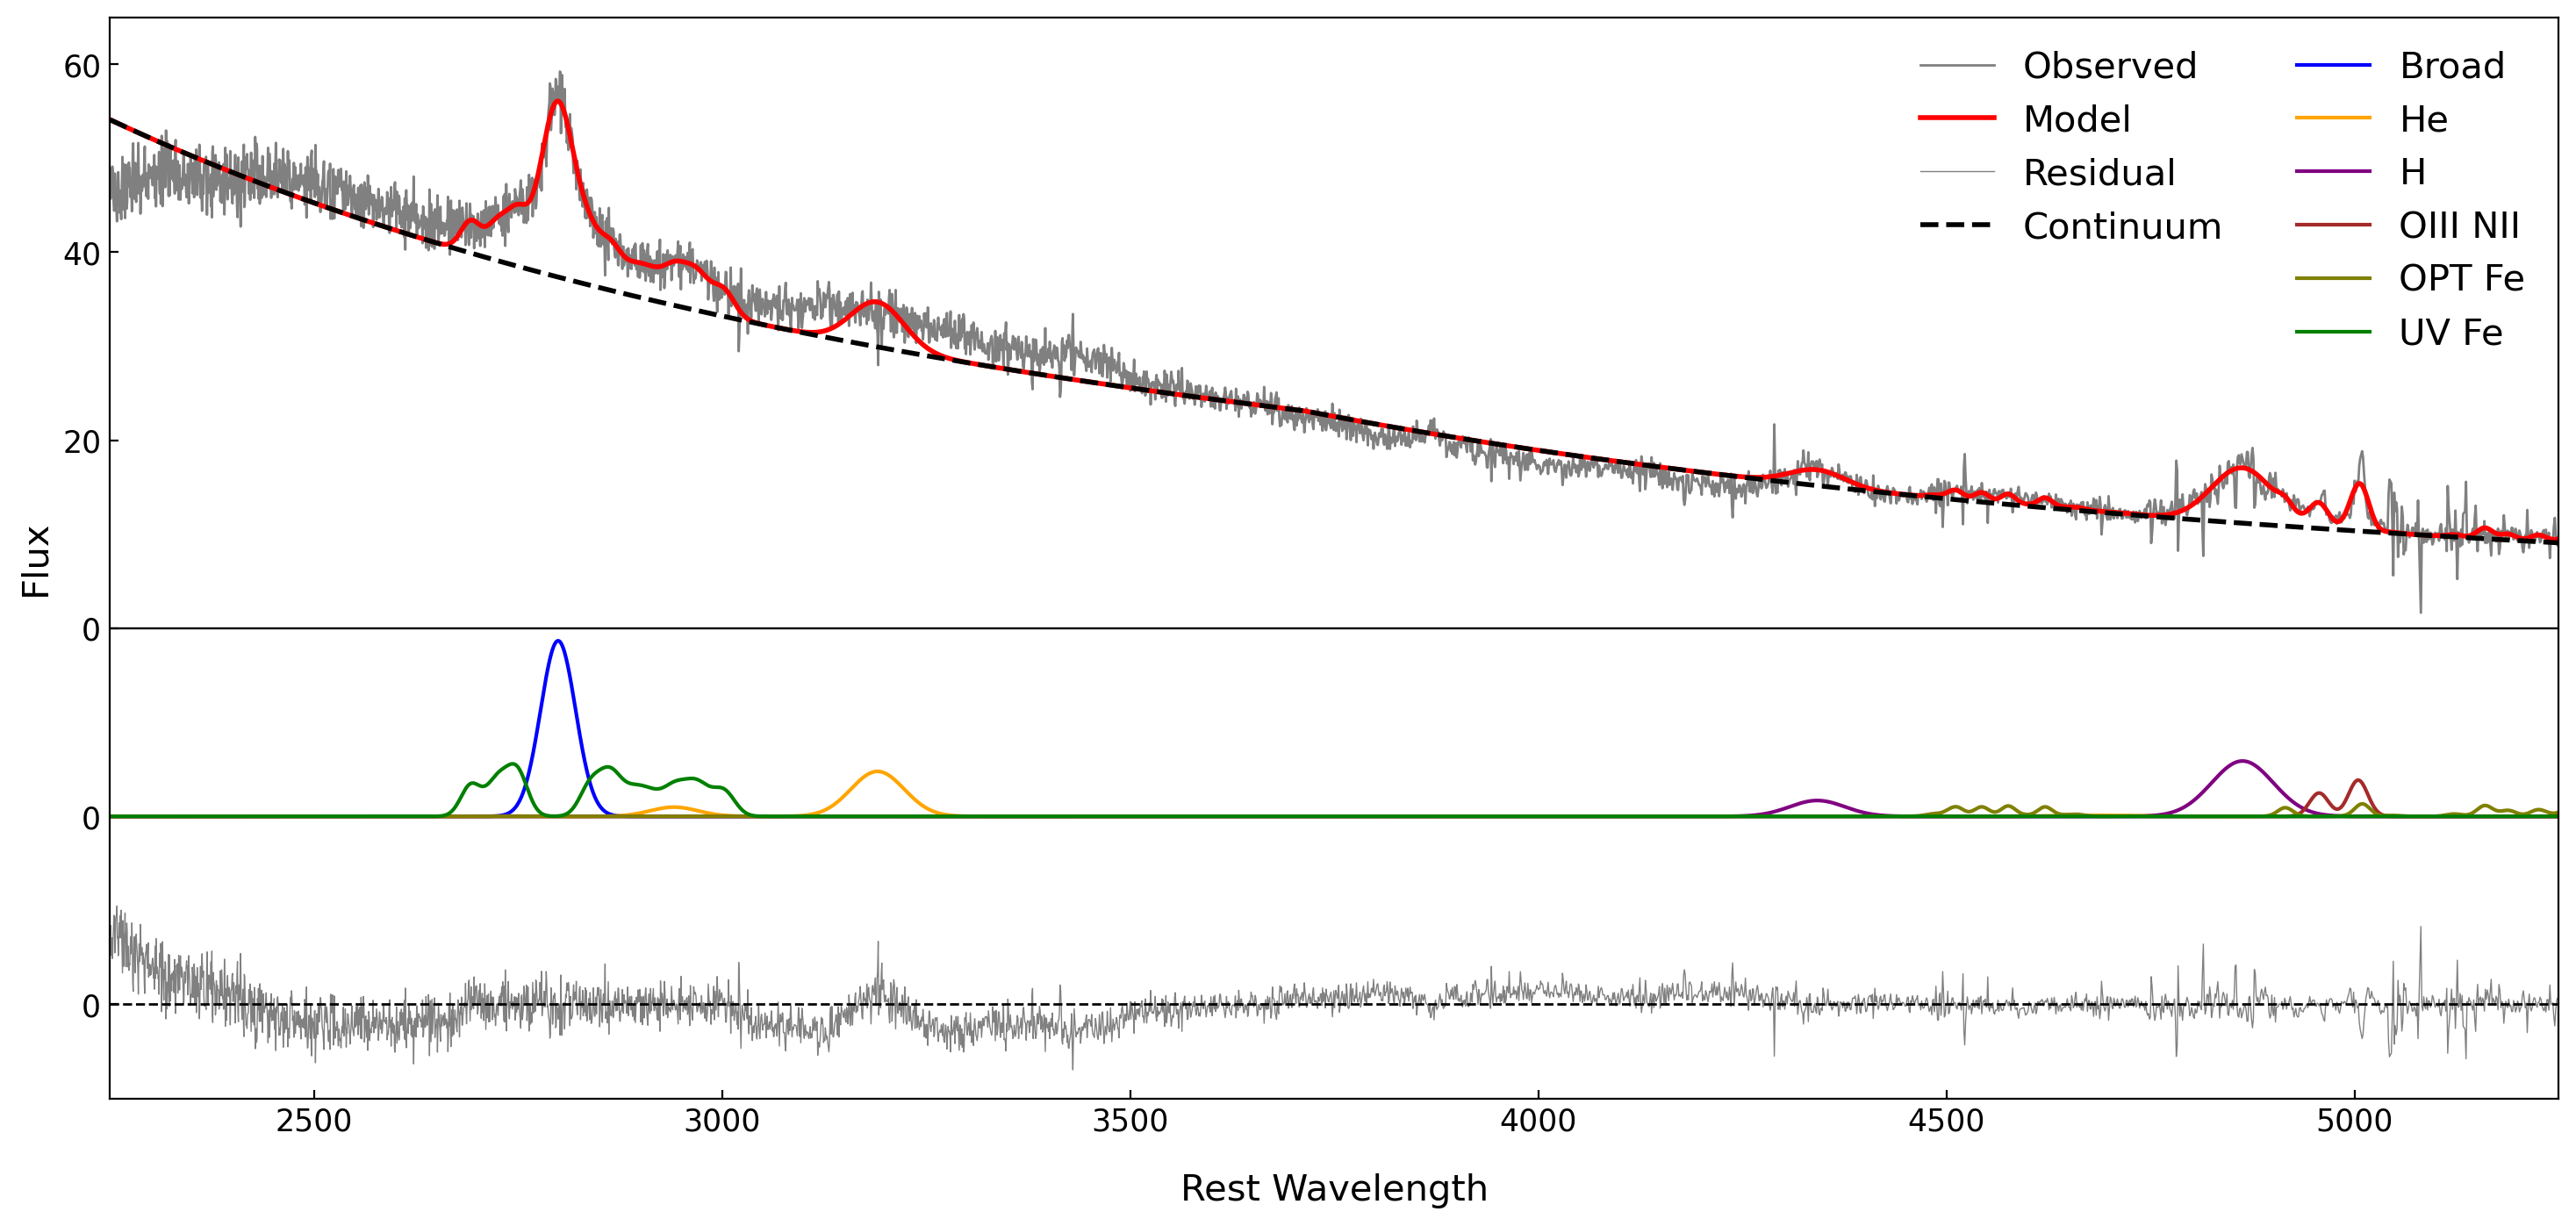


Method                = levmar
Statistic             = chi2
Initial fit statistic = 11126.1
Final fit statistic   = 11064.2 at function evaluation 1891
Data points           = 3679
Degrees of freedom    = 3576
Probability [Q-value] = 0
Reduced statistic     = 3.09401
Change in statistic   = 61.94
   brokenpowerlaw.refer   3713.31      +/- 11.328      
   brokenpowerlaw.ampl   23.1375      +/- 0.144026    
   brokenpowerlaw.index1   -1.69582     +/- 0.00501146  
   brokenpowerlaw.index2   -1           +/- 0.0292207   
   br.amp_MgII_2800   18.6744      +/- 5.49546     
   br.amp_NaI_5890   2            +/- 0           
   br.amp_NaI1_5896   2            +/- 0           
   br.amp_OI_6046   2            +/- 0           
   br.amp_OI_7002   2            +/- 0           
   br.amp_OI_7254   2            +/- 0           
   br.amp_OI_7774   2            +/- 0           
   br.offs_kms    -80.2323     +/- 1439.97     
   br.fwhm        5408.69      +/- 7383.28     
   h.amp_Heps_3970   0   

In [5]:
t=read_sdss(f'spectra/{specs[1]}.fits')

t.DeRedden()

t.CorRed()

print()
t.fit_host_sdss(mask_host=True, custom=False)
print()

plt.style.context(['nature', 'notebook'])
plt.figure(figsize=(10,5.5))
plt.title(specs[1].upper())
plt.plot(t.wave, t.flux, color="gray", label='Observation', lw=1)
plt.legend(loc='lower left',  prop={'size': 10}, frameon=False, ncol=2)

plt.show()
plt.close()

print('CROPPING...')
t.crop(2250, 5250)
print(f'\nmin: {min(t.wave):.2f}\nmax: {max(t.wave):.2f}\nlen: {len(t.wave)}\n')

t_cont=continuum(t, refer=3750, min_refer=3500, max_refer=4000)
t_broad=create_fixed_model(['broad.csv'], name='br')
t_h=create_fixed_model(['hydrogen.csv'], name='h')
t_he=create_fixed_model(['helium.csv'], name='he')
t_oiii_nii=create_fixed_model(['oiii_nii.csv'], name='on')
t_fe=create_feii_model(name='feii', fwhm=1000, min_fwhm=250, max_fwhm=1750, offset=0, min_offset=-3000, max_offset=3000)
t_uvfe=create_fixed_model(['uvfe.csv'], name='uvfe')

t_model = t_cont+t_broad+t_h+t_he+t_oiii_nii+t_fe+t_uvfe

print('FITTING...\n')
t.fit(t_model, ntrial=2)
print('\nPLOTTING...\n')

plt.style.context(['nature', 'notebook'])
plt.figure(figsize=(18,8))
plt.plot(t.wave, t.flux, label='Observed', color="gray", lw=1)
plt.plot(t.wave, t_model(t.wave), label='Model', color="red", lw=2)
plt.axhline(y=0, color='black', linestyle='-', lw=0.85)
plt.plot(t.wave, t_model(t.wave) - t.flux - 40, '-', label='Residual', color="gray", lw=0.5)
plt.axhline(y=-40, color='black', linestyle='--', lw=1)

plt.plot(t.wave, t_cont(t.wave), '--', label='Continuum', color="black", lw=2)
plt.plot([], [], ' ', label=' ')
plt.plot([], [], ' ', label=' ')
plt.plot(t.wave, t_broad(t.wave) - 20, label='Broad', color="blue", lw=1.5)
plt.plot(t.wave, t_he(t.wave) - 20, label='He', color="orange", lw=1.5)
plt.plot(t.wave, t_h(t.wave) - 20, label='H', color="purple", lw=1.5)
plt.plot(t.wave, t_oiii_nii(t.wave) - 20, '-', label='OIII NII', color="brown", lw=1.5)
plt.plot(t.wave, t_fe(t.wave) - 20, '-', label='OPT Fe', color="olive", lw=1.5)
plt.plot(t.wave, t_uvfe(t.wave) - 20, '-', label='UV Fe', color="green", lw=1.5)

plt.xlabel('Rest Wavelength',fontsize=15, labelpad=15)
plt.ylabel('Flux',fontsize=15)
plt.xlim(2250,5250)
plt.ylim(-50,65)
plt.tick_params(which='both', direction="in")
plt.xticks(np.arange(2500, 5500, 500), fontsize=12.5)
plt.yticks(np.arange(-40, 80, 20), ['0', '0', '0', '20', '40', '60'], fontsize=12.5)
plt.legend(loc='upper right',  prop={'size': 15}, frameon=False, ncol=2)

plt.show()
plt.close()

print()
print(t.gres.format())

- spectral window shows transition between near ultraviolet into restframe optical
- big blue bump accretion emission dominates steeply falling continuous component
- small blue bump FeII pseudo continuum bridge feature around broad MgII line in ultraviolet
- high velocity plasma with good agreement between MgII FWHM ~ 5400 km/s and Hβ FWHM ~ 5500 km/s
- low amplitude [OIII] contribution compared to FeII hints at high accretion rate

*--> Strong Quasar (direct view, massive central black hole, rapidly accreting)*